In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)


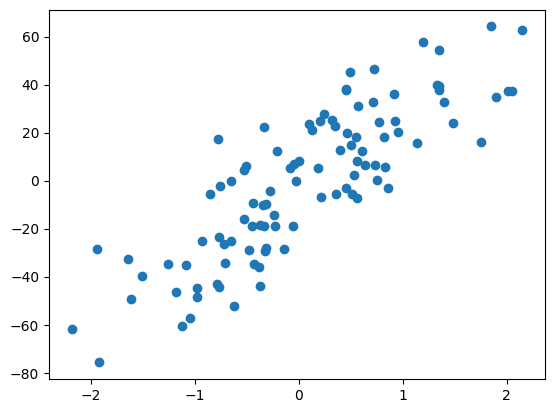

In [4]:
plt.scatter(X,y)

In [9]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)


[27.82809103]
-2.29474455867698


In [10]:
from sklearn.linear_model import Ridge

In [14]:
r=Ridge(alpha=10)
r.fit(X,y)
print(r.coef_)
print(r.intercept_)

[24.9546267]
-2.1269130035235735


In [21]:
r=Ridge(alpha=100)
r.fit(X,y)
print(r.intercept_)
print(r.coef_)

-1.4248441496033308
[12.93442104]


In [34]:
class scratchRidge:

  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.m=None
    self.b=None

  def fit(self,X,y):
    num=0
    den=0

    for i in range(X.shape[0]):
      num= num + (y - y.mean()) * (X - X.mean())
      den= den + (X - X.mean())*(X - X.mean())

      self.m=num/(den + self.alpha)
      self.b = y.mean() - (self.m*X.mean())
      print(self.m, self.b)


In [35]:
reg=scratchRidge(alpha=100)
reg.fit(X,y)


[[ 0.25784548  0.06706052  0.14113331 ...  0.46010028 -0.17549125
   0.01327783]
 [ 0.16634758  0.04326372  0.09105137 ...  0.29683115 -0.11321721
   0.00856612]
 [ 0.17189345  0.04470609  0.09408694 ...  0.3067272  -0.11699176
   0.00885171]
 ...
 [ 0.39127251  0.10176226  0.21416542 ...  0.69818789 -0.26630253
   0.0201487 ]
 [ 0.13140048  0.03417467  0.07192286 ...  0.23447142 -0.08943199
   0.00676651]
 [ 0.27272585  0.07093061  0.14927817 ...  0.48665286 -0.18561893
   0.0140441 ]] [[-0.68443844 -0.67329519 -0.67762159 ... -0.69625162 -0.65912837
  -0.67015388]
 [-0.67909429 -0.67190528 -0.67469643 ... -0.68671549 -0.66276564
  -0.66987869]
 [-0.67941821 -0.67198953 -0.67487373 ... -0.6872935  -0.66254518
  -0.66989537]
 ...
 [-0.69223157 -0.67532203 -0.6818872  ... -0.71015769 -0.65382433
  -0.67055519]
 [-0.67705312 -0.67137441 -0.67357919 ... -0.68307322 -0.66415487
  -0.66977357]
 [-0.68530757 -0.67352123 -0.67809731 ... -0.69780249 -0.65853684
  -0.67019864]]
[[ 0.51266307  0

In [38]:
from sklearn.datasets import load_diabetes

In [44]:
X,y = load_diabetes(return_X_y=True)


In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=37,test_size=0.2)

In [48]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [51]:
predict=lr.predict(X_test)
predict

array([148.36764655, 193.19168129, 244.02727137, 178.04982261,
        52.73851506,  73.91428096, 193.30754755, 212.06038714,
       182.525738  , 221.78915742, 259.29480149, 251.87324061,
       186.54030845, 116.4136452 , 160.4256357 ,  65.34828734,
       139.11747442,  72.75748182,  92.04790912, 184.80629145,
        69.40276047, 144.45551891, 161.54526891,  67.631094  ,
       173.08385643, 136.66565376, 223.95714507, 219.05254142,
       109.9430828 , 125.16976682, 158.81998947, 157.39035087,
        86.23829575, 148.60325374,  46.54089891, 246.81473725,
       214.27745558, 179.95809483, 114.37343497, 207.94749045,
        33.534301  , 128.22489598, 108.31354201, 158.3425487 ,
       208.10189465, 102.60675523, 230.04655094, 104.0183191 ,
       164.5356643 ,  74.33342029,  59.90438621, 198.20024158,
       153.96283149, 164.944234  ,  77.91551504, 236.61275071,
       181.38005289, 126.29846498, 134.54650552, 113.3192365 ,
       101.67869004, 247.67209636, 139.00582171, 207.89

In [52]:
from sklearn.metrics import r2_score
r2_score(predict,y_test)

0.027769852214783564

In [58]:
lr.coef_

array([ -27.75402306, -273.9551867 ,  495.16993009,  373.52712697,
       -798.60305586,  534.1789761 ,   52.05703259,  148.64249047,
        720.9447616 ,   55.65240207])

# With regularization

In [56]:
class scratchRegularization:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.coef_=None
    self.intercept_=None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1)
    I= np.identity(X_train.shape[1])
    I[0][0] = 0 #intercept does not need to be updated
    result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
    self.intercept_=result[0]
    self.coef_=result[1:]

  def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_


In [57]:
reg = scratchRegularization()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.5047670194053522
[ -15.72064718 -224.91973668  456.68992417  339.6605366   -71.87707916
  -39.55061572 -214.72135259  108.60324539  402.12874482   78.23082037]
152.80391890883425
